In [3]:
import pandas as pd

df = pd.read_csv("data.csv")
print(df.shape)
print(df.columns)
print(df.dtypes)
df.info()
df.head()

(32, 5)
Index(['Duration', 'Date', 'Pulse', 'Maxpulse', 'Calories'], dtype='str')
Duration      int64
Date            str
Pulse         int64
Maxpulse      int64
Calories    float64
dtype: object
<class 'pandas.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Duration  32 non-null     int64  
 1   Date      31 non-null     str    
 2   Pulse     32 non-null     int64  
 3   Maxpulse  32 non-null     int64  
 4   Calories  30 non-null     float64
dtypes: float64(1), int64(3), str(1)
memory usage: 1.4 KB


,Duration,Date,Pulse,Maxpulse,Calories
0,60,'2020/12/01',110,130,409.1
1,60,'2020/12/02',117,145,479.0
2,60,'2020/12/03',103,135,340.0
3,45,'2020/12/04',109,175,282.4
4,45,'2020/12/05',117,148,406.0


In [4]:
df["Date"] = df["Date"].astype(str).str.strip("'")
df["Date"] = pd.to_datetime(df["Date"],format="%Y/%m/%d",errors="coerce")
print(df["Date"])

0    2020-12-01
1    2020-12-02
2    2020-12-03
3    2020-12-04
4    2020-12-05
5    2020-12-06
6    2020-12-07
7    2020-12-08
8    2020-12-09
9    2020-12-10
10   2020-12-11
11   2020-12-12
12   2020-12-12
13   2020-12-13
14   2020-12-14
15   2020-12-15
16   2020-12-16
17   2020-12-17
18   2020-12-18
19   2020-12-19
20   2020-12-20
21   2020-12-21
22          NaT
23   2020-12-23
24   2020-12-24
25   2020-12-25
26          NaT
27   2020-12-27
28   2020-12-28
29   2020-12-29
30   2020-12-30
31   2020-12-31
Name: Date, dtype: datetime64[us]


In [6]:
print(df[df["Date"].isna()])
print(df.isnull().sum())

    Duration Date  Pulse  Maxpulse  Calories
22        45  NaT    100       119     282.0
26        60  NaT    100       120     250.0
Duration    0
Date        2
Pulse       0
Maxpulse    0
Calories    2
dtype: int64


In [8]:
df["Calories"] = df["Calories"].fillna(df["Calories"].mean())
df = df.dropna(subset=['Date'])

In [11]:
print(df.duplicated().sum())
df = df.drop_duplicates()
print(df.shape)

0
(29, 5)


In [12]:

long_sessions = df[df["Duration"] > 60]
print(long_sessions)


efficient_sessions = df[(df["Calories"] > 300) & (df["Pulse"] < 100)]
print(efficient_sessions)

   Duration       Date  Pulse  Maxpulse  Calories
7       450 2020-12-08    104       134     253.3
    Duration       Date  Pulse  Maxpulse  Calories
18        45 2020-12-18     90       112    304.68


In [13]:
print(df[df["Duration"] > 200])  

df.loc[df["Duration"] > 200, "Duration"] = 120

   Duration       Date  Pulse  Maxpulse  Calories
7       450 2020-12-08    104       134     253.3


In [14]:

df["Calories_per_Minute"] = df["Calories"] / df["Duration"]


def label_intensity(pulse):
    if pulse < 100:
        return "Low"
    elif pulse <= 120:
        return "Medium"
    else:
        return "High"

df["Intensity"] = df["Pulse"].apply(label_intensity)
print(df[["Pulse", "Intensity", "Calories_per_Minute"]].head(10))

   Pulse Intensity  Calories_per_Minute
0    110    Medium             6.818333
1    117    Medium             7.983333
2    103    Medium             5.666667
3    109    Medium             6.275556
4    117    Medium             9.022222
5    102    Medium             5.000000
6    110    Medium             6.233333
7    104    Medium             2.110833
8    109    Medium             6.503333
9     98       Low             4.483333


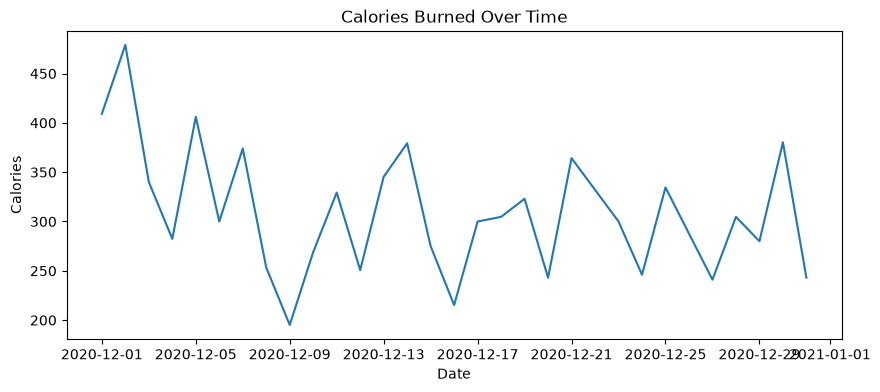

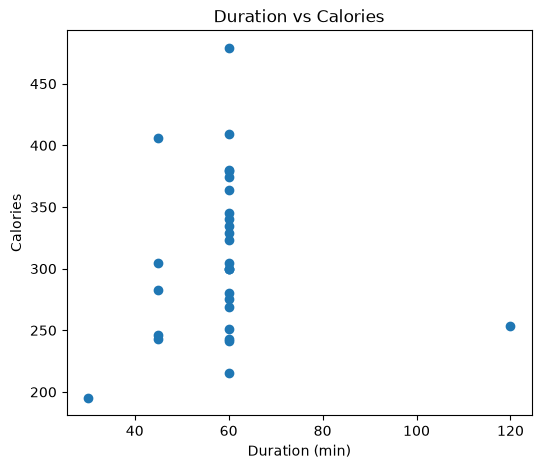

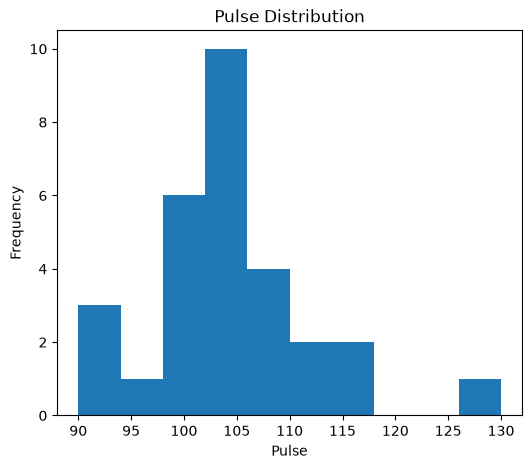

In [15]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 4))
plt.plot(df["Date"], df["Calories"])
plt.title("Calories Burned Over Time")
plt.xlabel("Date")
plt.ylabel("Calories")
plt.show()


plt.figure(figsize=(6, 5))
plt.scatter(df["Duration"], df["Calories"])
plt.title("Duration vs Calories")
plt.xlabel("Duration (min)")
plt.ylabel("Calories")
plt.show()


plt.figure(figsize=(6, 5))
plt.hist(df["Pulse"], bins=10)
plt.title("Pulse Distribution")
plt.xlabel("Pulse")
plt.ylabel("Frequency")
plt.show()